<a href="https://colab.research.google.com/github/nosadchiy/public/blob/main/Newsvendor_AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Actor-Critic (A2C) for the single-period Newsvendor problem
# Note Bias-Variance tradeoff, see variance clamping log_std = torch.clamp(self.log_std_u, -2.0, 2.0)
# Tru lower bound -6 to get rid of the bias (but increase variance)

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -----------------------------
# Problem setup
# -----------------------------
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

mu_demand = 100.0
sigma_demand = 20.0

overage_cost  = 1.0   # c_o
shortage_cost = 5.0   # c_s

# Theoretical optimum (Newsvendor critical fractile)
alpha = shortage_cost / (shortage_cost + overage_cost)
z = torch.distributions.Normal(0.0, 1.0).icdf(torch.tensor(alpha, dtype=dtype))
Q_star = (mu_demand + sigma_demand * z).item()

# Action space upper bound for the policy (keep comfortably above optimum)
MAX_ORDER = 250.0

# -----------------------------
# Actor-Critic model (contextual bandit)
# State is constant (IID demand), so we learn a stationary policy.
# We use a "squashed" Gaussian policy: u ~ N(mean_u, std_u), a = MAX_ORDER * sigmoid(u)
# This keeps a in (0, MAX_ORDER) and is stable + fast.
# -----------------------------
class Actor(nn.Module):
    def __init__(self, max_order: float):
        super().__init__()
        self.max_order = float(max_order)
        # Two trainable scalars = fastest possible "neural" policy
        self.mean_u = nn.Parameter(torch.tensor(0.0, dtype=dtype))
        self.log_std_u = nn.Parameter(torch.tensor(0.0, dtype=dtype))  # std_u starts at 1.0

    def dist(self):
        # try increasing lower bound to -2
        log_std = torch.clamp(self.log_std_u, -2.0, 2.0)  # std in [~0.0025, ~7.4]
        std = torch.exp(log_std)
        return torch.distributions.Normal(self.mean_u, std)

    @torch.no_grad()
    def mean_action(self):
        # Deterministic order implied by mean_u
        return self.max_order * torch.sigmoid(self.mean_u).item()

    def sample_action_and_logp(self, batch_size: int):
        """
        Sample action a and compute log pi(a) with change-of-variables correction.
        Important: we use dist.sample (NOT rsample) to avoid the "log_prob gradient cancels" pitfall.
        """
        d = self.dist()
        u = d.sample((batch_size,)).to(device)  # sampled w/out grad path through u

        sig = torch.sigmoid(u)
        a = self.max_order * sig

        # log p(u)
        logp_u = d.log_prob(u)

        # log |da/du| = log(MAX_ORDER) + log(sigmoid(u)) + log(1 - sigmoid(u))
        # use stable logs:
        log_sig = -F.softplus(-u)  # log(sigmoid(u))
        log1m  = -F.softplus(u)   # log(1 - sigmoid(u))
        log_det = math.log(self.max_order) + log_sig + log1m

        logp_a = logp_u - log_det
        return a, logp_a

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        # Constant baseline (fastest possible critic for constant state)
        self.V = nn.Parameter(torch.tensor(0.0, dtype=dtype))

    def forward(self, batch_size: int):
        return self.V.expand(batch_size)

actor = Actor(MAX_ORDER).to(device)
critic = Critic().to(device)

opt_actor  = torch.optim.Adam(actor.parameters(),  lr=0.03)
opt_critic = torch.optim.Adam(critic.parameters(), lr=0.08)

# -----------------------------
# Environment + training
# -----------------------------
def sample_demand(n: int):
    return (mu_demand + sigma_demand * torch.randn(n, device=device, dtype=dtype))

def reward_from_action_and_demand(a, d):
    # reward = - cost
    shortage = F.relu(d - a)
    overage  = F.relu(a - d)
    cost = shortage_cost * shortage + overage_cost * overage
    return -cost

def train_a2c(
    steps: int = 1200,
    batch_size: int = 8192,
    entropy_coef_start: float = 0.02,  # exploration early
    print_every: int = 200,
):
    q_means_history = []
    std_history = []

    for t in range(steps):
        # Entropy bonus anneals to 0 for precision at convergence
        ent_coef = entropy_coef_start * (1.0 - t / max(1, steps - 1))

        d = sample_demand(batch_size)
        a, logp = actor.sample_action_and_logp(batch_size)

        r = reward_from_action_and_demand(a, d).detach()  # detach reward (score-function estimator)
        V = critic(batch_size)

        adv = (r - V.detach())
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        critic_loss = ((r - V) ** 2).mean()

        # entropy approx = E[-log pi(a)]
        entropy = (-logp).mean()
        actor_loss = -(logp * adv).mean() - ent_coef * entropy

        opt_critic.zero_grad()
        critic_loss.backward()
        opt_critic.step()

        opt_actor.zero_grad()
        actor_loss.backward()
        opt_actor.step()

        # Record q_mean and std_u at every step
        with torch.no_grad():
            q_mean = actor.mean_action()
            current_std = actor.dist().scale.item()

        q_means_history.append(q_mean)
        std_history.append(current_std)

        if (t % print_every) == 0 or (t == steps - 1):
            with torch.no_grad():
                avg_r = r.mean().item()
            print(f"step {t:4d} | avg_reward {avg_r:9.3f} | Q_mean {q_mean:8.3f} | std_u {current_std:7.4f}")

    return q_means_history, std_history

steps = 1200
print_every = 200
q_history, std_history = train_a2c(steps=steps, print_every=print_every)

Q_rl = actor.mean_action()

print("\n--- Order quantities ---")
print(f"Theoretical Q*  : {Q_star:.6f}")
print(f"RL learned Q    : {Q_rl:.6f}")
print(f"Abs error       : {abs(Q_rl - Q_star):.6f}")

# -----------------------------
# Performance comparison (Monte Carlo expected cost)
# -----------------------------
@torch.no_grad()
def expected_cost(order_qty: float, n: int = 300_000):
    d = sample_demand(n)
    a = torch.full((n,), float(order_qty), device=device, dtype=dtype)
    shortage = F.relu(d - a)
    overage  = F.relu(a - d)
    cost = shortage_cost * shortage + overage_cost * overage
    return cost.mean().item()

c_star = expected_cost(Q_star)
c_rl   = expected_cost(Q_rl)
c_mu   = expected_cost(mu_demand)

print("\n--- Expected cost (lower is better) ---")
print(f"Cost at Q*      : {c_star:.6f}")
print(f"Cost at RL Q    : {c_rl:.6f}   (gap vs Q*: {(c_rl/c_star - 1)*100:.3f}")
print(f"Cost at Q=mu    : {c_mu:.6f}   (baseline: order mean demand)")

step    0 | avg_reward  -100.926 | Q_mean  126.875 | std_u  0.9704
step  200 | avg_reward   -32.798 | Q_mean  120.372 | std_u  0.1353
step  400 | avg_reward   -32.395 | Q_mean  121.410 | std_u  0.1353
step  600 | avg_reward   -32.406 | Q_mean  121.218 | std_u  0.1353
step  800 | avg_reward   -32.692 | Q_mean  120.987 | std_u  0.1353
step 1000 | avg_reward   -33.021 | Q_mean  120.395 | std_u  0.1353
step 1199 | avg_reward   -32.895 | Q_mean  121.797 | std_u  0.1353

--- Order quantities ---
Theoretical Q*  : 119.348427
RL learned Q    : 121.796750
Abs error       : 2.448323

--- Expected cost (lower is better) ---
Cost at Q*      : 29.926466
Cost at RL Q    : 30.174316   (gap vs Q*: 0.828
Cost at Q=mu    : 48.093815   (baseline: order mean demand)


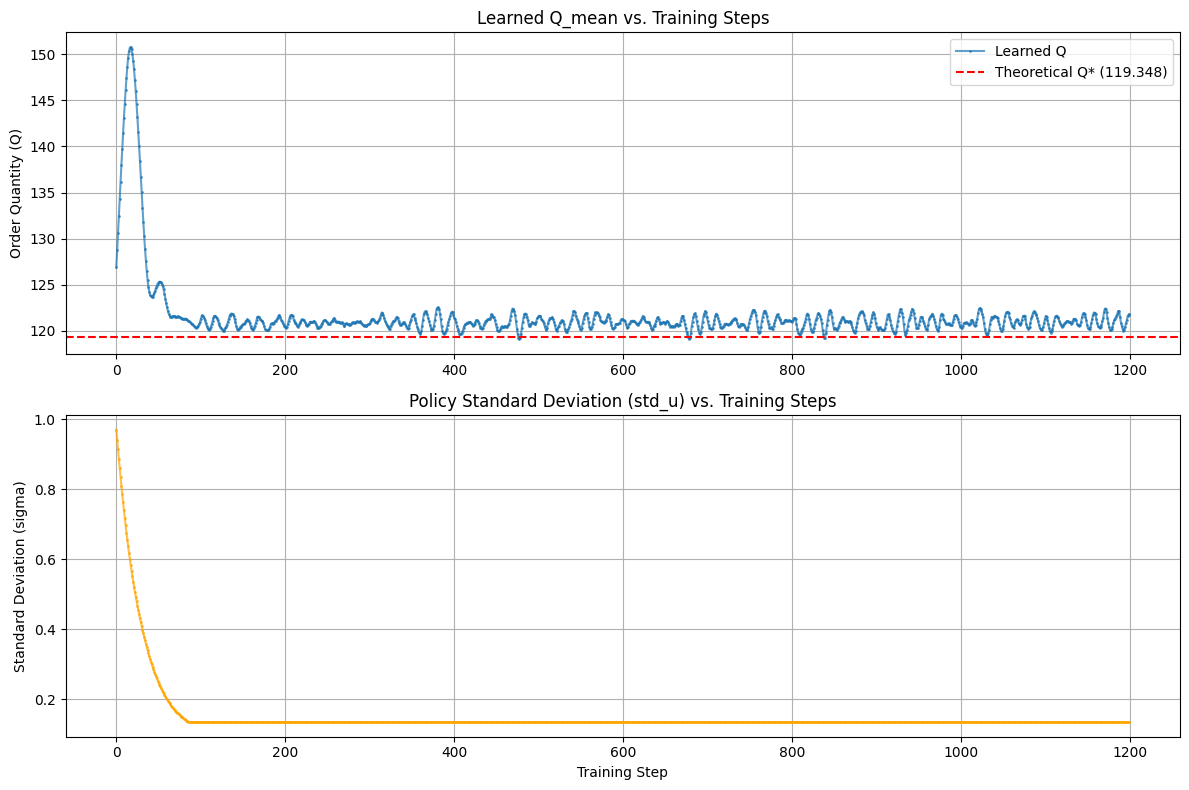

In [2]:
plt.figure(figsize=(12, 8))
steps_list = list(range(steps))

# Plot 1: Learned Q_mean
plt.subplot(2, 1, 1)
plt.plot(steps_list, q_history, marker='.', linestyle='-', markersize=2, alpha=0.7, label='Learned Q')
plt.axhline(y=Q_star, color='r', linestyle='--', label=f'Theoretical Q* ({Q_star:.3f})')
plt.title('Learned Q_mean vs. Training Steps')
plt.ylabel('Order Quantity (Q)')
plt.grid(True)
plt.legend()

# Plot 2: Policy Standard Deviation
plt.subplot(2, 1, 2)
plt.plot(steps_list, std_history, color='orange', marker='.', markersize=2, alpha=0.7)
plt.title('Policy Standard Deviation (std_u) vs. Training Steps')
plt.xlabel('Training Step')
plt.ylabel('Standard Deviation (sigma)')
plt.grid(True)

plt.tight_layout()
plt.show()